# Data Visualization

In [10]:
!pip install seaborn 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#Load the 'taxis' dataset
df = sns.load_dataset("taxis")
df

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


In [2]:
df.shape

(6433, 14)

## df.info()
- Purpose: Provides metadata about the dataset.
- Output: Number of rows, column names, data types, and count of non-null values.
- Use case: Helps you identify missing values and understand column types (numeric, categorical, datetime).

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[us]
 1   dropoff          6433 non-null   datetime64[us]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   str           
 9   payment          6389 non-null   str           
 10  pickup_zone      6407 non-null   str           
 11  dropoff_zone     6388 non-null   str           
 12  pickup_borough   6407 non-null   str           
 13  dropoff_borough  6388 non-null   str           
dtypes: datetime64[us](2), float64(5), int64(1), str(6)


## 2) Handling Missing Values

In [4]:
# ● Check for missing values in the dataset and identify columns with missing data.
# ● Impute missing values using appropriate strategies based on the column type (e.g.,
# using the mean, median, or mode for numerical columns and the mode for categorical
# columns).
# ● For columns that are critical and cannot be reasonably imputed, remove rows with
# missing values to maintain data integrity.

- Numerical columns → use mean/median.
- Categorical columns → use mode.
- Critical columns → drop rows to maintain integrity.

In [5]:
import warnings
warnings.filterwarnings('ignore')

## df.describe() </u>
- Purpose: Gives a quick statistical summary of numerical columns.
- Output: Count, mean, standard deviation, min, max, and quartiles (25%, 50%, 75%).
- Use case: Helps you understand the distribution of values (e.g., average fare, typical distance).


In [6]:
df.describe(include='object')

,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
count,6433,6389,6407,6388,6407,6388
unique,2,2,194,203,4,5
top,yellow,credit card,Midtown Center,Upper East Side North,Manhattan,Manhattan
freq,5451,4577,230,245,5268,5206


In [7]:
df.describe(include='number')

,passengers,distance,fare,tip,tolls,total
count,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
std,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570
min,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000


In [8]:
round(df.isnull().mean()*100,1)

pickup             0.0
dropoff            0.0
passengers         0.0
distance           0.0
fare               0.0
tip                0.0
tolls              0.0
total              0.0
color              0.0
payment            0.7
pickup_zone        0.4
dropoff_zone       0.7
pickup_borough     0.4
dropoff_borough    0.7
dtype: float64

In [9]:
df.isnull().sum()

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

## Finding mode for categorical column to fill null values.

In [10]:
df['payment'].mode()

0    credit card
Name: payment, dtype: str

In [11]:
df['pickup_zone'].mode()

0    Midtown Center
Name: pickup_zone, dtype: str

In [12]:
df['dropoff_zone'].mode()

0    Upper East Side North
Name: dropoff_zone, dtype: str

In [13]:
df['pickup_borough'].mode()

0    Manhattan
Name: pickup_borough, dtype: str

In [14]:
df['dropoff_borough'].mode()

0    Manhattan
Name: dropoff_borough, dtype: str

In [15]:
# Replace empty strings, spaces, or 'NULL' with actual NaN
df['payment'].replace(["", " ", "NULL", "Na", "NA"], np.nan, inplace=True)

# Now fill all NaN with mode
df['payment'].fillna(df['payment'].mode()[0], inplace=True)


0       credit card
1              cash
2       credit card
3       credit card
4       credit card
           ...     
6428    credit card
6429    credit card
6430           cash
6431    credit card
6432    credit card
Name: payment, Length: 6433, dtype: str

In [16]:
df["payment"].count()

np.int64(6389)

In [17]:
df.isnull().sum()

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

In [18]:
print("Nulls left:", df['payment'].isnull().sum())
print("Count     :", df['payment'].count())
print("Total rows:", len(df))


Nulls left: 44
Count     : 6389
Total rows: 6433


In [19]:
# Look at rows where payment is still missing
print(df.loc[df['payment'].isnull(), 'payment'].head(10))

# Also check unique values
print(df['payment'].unique())


7       NaN
445     NaN
491     NaN
545     NaN
621     NaN
770     NaN
913     NaN
953     NaN
1207    NaN
1372    NaN
Name: payment, dtype: str
<StringArray>
['credit card', 'cash', nan]
Length: 3, dtype: str


In [20]:
df['payment'] = df['payment'].astype('object')
df['payment'].fillna(df['payment'].mode()[0], inplace=True)


0       credit card
1              cash
2       credit card
3       credit card
4       credit card
           ...     
6428    credit card
6429    credit card
6430           cash
6431    credit card
6432    credit card
Name: payment, Length: 6433, dtype: object

In [21]:
import pandas as pd

df['payment'] = df['payment'].replace(pd.NA, df['payment'].mode()[0])


In [22]:
df['payment'] = df['payment'].fillna(df['payment'].mode()[0])


In [23]:
print("Nulls left:", df['payment'].isnull().sum())
print("Count     :", df['payment'].count())
print("Total rows:", len(df))


Nulls left: 0
Count     : 6433
Total rows: 6433


In [24]:
df['pickup_zone'] = df['pickup_zone'].fillna(df['pickup_zone'].mode()[0])
print("Nulls left:", df['pickup_zone'].isnull().sum())
print("Count     :", df['pickup_zone'].count())
print("Total rows:", len(df))


Nulls left: 0
Count     : 6433
Total rows: 6433


In [39]:
df['dropoff_zone'] = df['dropoff_zone'].fillna(df['dropoff_zone'].mode()[0])
print("Nulls left:", df['dropoff_zone'].isnull().sum())
print("Count     :", df['dropoff_zone'].count())
print("Total rows:", len(df))


Nulls left: 0
Count     : 6433
Total rows: 6433


In [26]:

df['pickup_borough'] = df['pickup_borough'].fillna(df['pickup_borough'].mode()[0])
print("Nulls left:", df['pickup_borough'].isnull().sum())
print("Count     :", df['pickup_borough'].count())
print("Total rows:", len(df))


Nulls left: 0
Count     : 6433
Total rows: 6433


In [27]:
   
df['dropoff_borough'] = df['dropoff_borough'].fillna(df['dropoff_borough'].mode()[0])
print("Nulls left:", df['dropoff_borough'].isnull().sum())
print("Count     :", df['dropoff_borough'].count())
print("Total rows:", len(df))


Nulls left: 0
Count     : 6433
Total rows: 6433


In [28]:
# checking null values after using fillna
df.isnull().sum()

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment             0
pickup_zone         0
dropoff_zone       45
pickup_borough      0
dropoff_borough     0
dropff_zone         0
dtype: int64

## 3) Visualizations using Matplotlib/Pandas Plot:
★ Line Chart
Plot a line chart to visualize the fare over time, using the pickup timestamp as the x-axis and
fare as the y-axis. Ensure the pickup column is converted to a datetime format before plotting.

- Shows how fares vary across time.
- Useful for identifying peak hours or seasonal trends.

In [29]:
df['pickup'] = pd.to_datetime(df['pickup'])

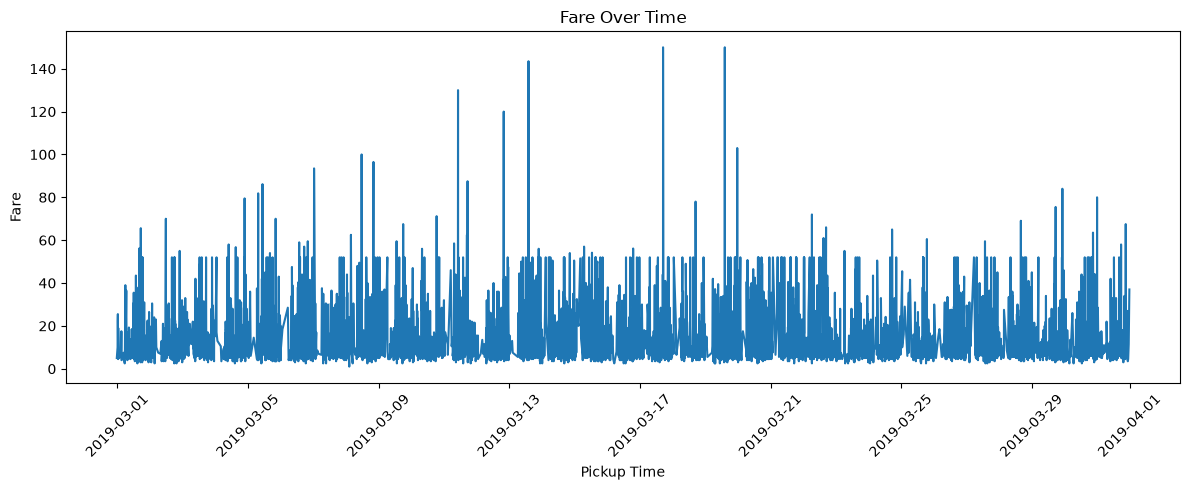

In [30]:
df = df.sort_values('pickup')

plt.figure(figsize=(12, 5))

plt.plot(df['pickup'], df['fare'])

plt.xlabel('Pickup Time')
plt.ylabel('Fare')
plt.title('Fare Over Time')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## 2) Bar Chart — Total Fare by Pickup Borough
Create a bar chart to show the total fare for each pickup_borough. Group the data by
pickup_borough and sum the fare for each group.


- groupby('pickup_borough') → groups taxis by borough
- ['fare'] → selects the fare column
- sum() → adds all fares in each borough

In [31]:
total_fare = df.groupby('pickup_borough')['fare'].sum()
total_fare


pickup_borough
Bronx         2078.91
Brooklyn      6327.48
Manhattan    59426.42
Queens       16382.06
Name: fare, dtype: float64

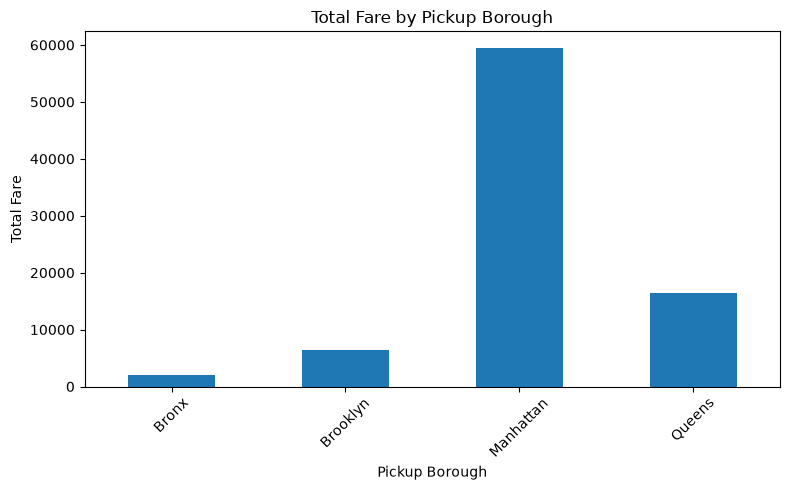

In [32]:
import matplotlib.pyplot as plt

total_fare.plot(kind='bar', figsize=(8, 5))

plt.xlabel('Pickup Borough')
plt.ylabel('Total Fare')
plt.title('Total Fare by Pickup Borough')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## 3) ★ Pie Chart— Trips by Payment Method
Plot a pie chart showing the distribution of trips based on the payment method (credit card,
cash, etc.). Each slice should represent the count of trips for a specific payment method.


Step 1: Count payment methods
- Plot a pie chart showing the distribution of trips based on the payment method.
- We need to count how many trips used each payment method.

In [33]:
# We need to count how many trips used each payment method.
payment_counts = df['payment'].value_counts()
payment_counts

payment
credit card    4621
cash           1812
Name: count, dtype: int64

## Pie chart
- value_counts() → counts the number of trips for each payment method
- labels= → displays payment method names
- autopct='%1.1f%%' → displays the percentage on each slice
- plt.pie() → creates the pie chart

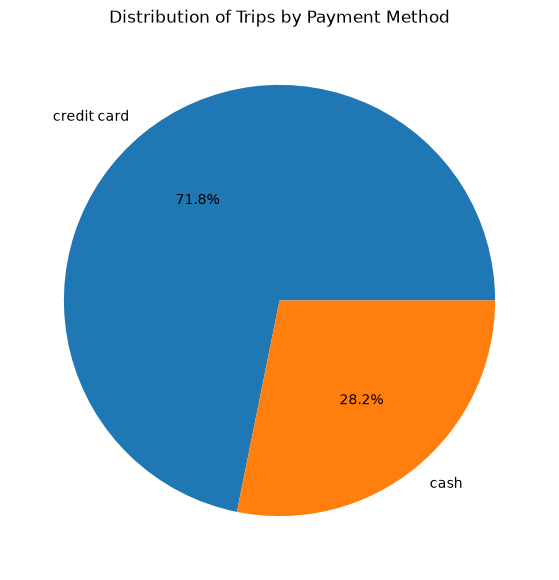

In [80]:
plt.figure(figsize=(7, 7))

plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct='%1.1f%%'
)

plt.title('Distribution of Trips by Payment Method')

plt.show()

## Step 4: Histogram
- Create a histogram to visualize the distribution of distance. Customize the number of bins for
better granularity and ensure the plot is easy to interpret.

- The histogram helps you see how the taxi trip distances are distributed. The X-axis shows distance ranges, while the Y-axis shows how many trips fall into each range.
- Reveals common trip lengths.
- Helps identify short vs long trip patterns.

  ### Explaination
- df["distance"] → uses the distance column.
- bins=20 → divides the distance values into 20 groups.


In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df["distance"], bins=20, edgecolor="black")            
                                                               
plt.xlabel("Distance")
plt.ylabel("Number of Trips")
plt.title("Distribution of Trip Distance")

plt.show()



## Step 5: Box Plot – Tip Amount by Pickup Borough
★ Box Plot
Plot a box plot to visualize the distribution of tip amounts for each pickup_borough. Use
pickup_borough as the categorical axis and tip as the numeric axis.

The box plot helps you understand:

- Median tip → middle value
- Spread of tips → how much tip values vary
- Outliers → unusually high or low tip values
- Comparison between boroughs
- Shows variation in tips across boroughs.
- Detects outliers and customer tipping behavior.

In [12]:
import warnings
warnings.filterwarnings('ignore')

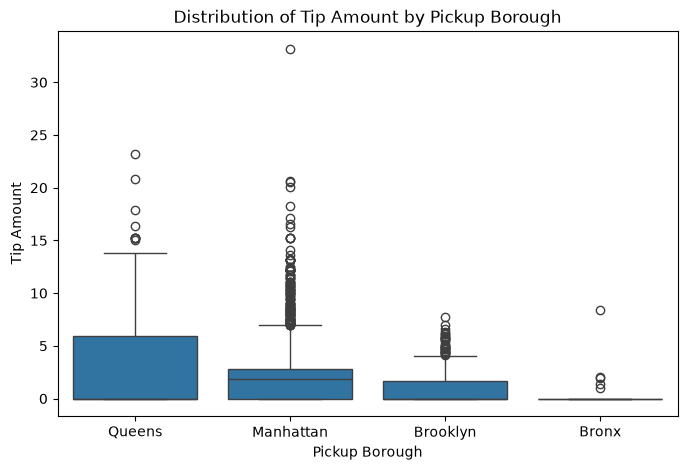

In [40]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="pickup_borough", y="tip", data=df)

plt.title("Distribution of Tip Amount by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Tip Amount")
plt.show()


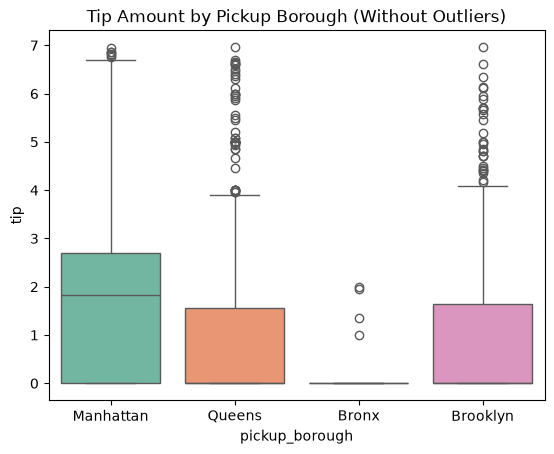

In [13]:
# Handling Outliers
Q1 = df['tip'].quantile(0.25)
Q3 = df['tip'].quantile(0.75)
IQR = Q3 - Q1

# Define upper and lower bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
df_no_outliers = df[(df['tip'] >= lower_bound) & (df['tip'] <= upper_bound)]

sns.boxplot(x="pickup_borough", y="tip", data=df_no_outliers, palette="Set2")
plt.title("Tip Amount by Pickup Borough (Without Outliers)")
plt.show()


# Visualizations using Seaborn:
## ★ Count Plot
- Create a count plot to visualize the number of trips in each pickup_borough. The x-axis should
represent the boroughs, and the y-axis should show the count of trips.
- Simple frequency comparison of boroughs.

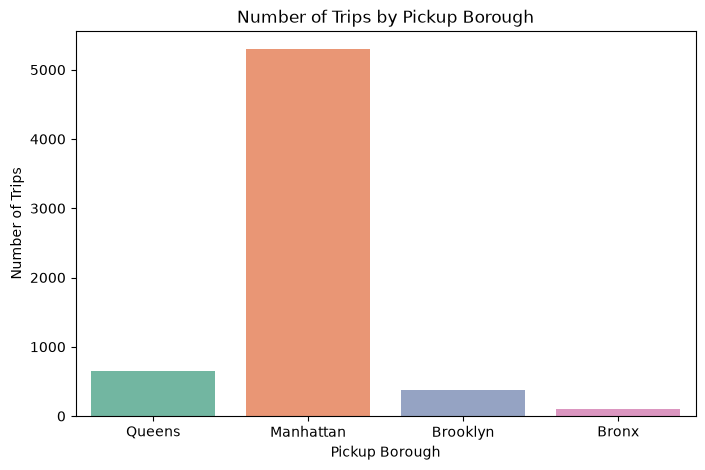

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.countplot(x="pickup_borough", data=df, palette="Set2")

plt.title("Number of Trips by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Number of Trips")

plt.show()


## ★ Scatter Plot
Plot a scatter plot to show the relationship between distance and fare. Use distance on the
x-axis and fare on the y-axis to visualize any correlation. Color the points based on the
pickup_borough to differentiate the trips by their respective boroughs.

- Shows correlation between distance and fare.
- Color coding reveals borough differences.

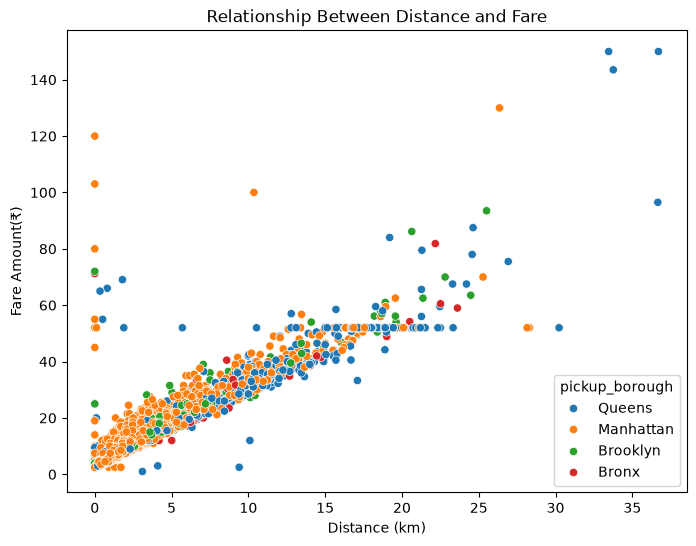

In [42]:
#Scatter Plot

plt.figure(figsize=(8, 6))
sns.scatterplot(x="distance", y="fare", data=df,hue="pickup_borough")             

plt.title("Relationship Between Distance and Fare")
plt.xlabel("Distance (km)")
plt.ylabel("Fare Amount(₹)")
plt.show()


## ★ Heatmap-- Correlation Matrix
- Plot a heatmap to visualize the correlation between numerical variables such as distance, fare,
tip, tolls, and total. Use a correlation matrix to highlight the relationships.

- df[["distance", "fare", "tip", "tolls", "total"]].corr() → Calculates the correlation matrix for these numerical columns.
- Heatmap → Visualizes correlations:
- Close to +1 → Strong positive correlation (both increase together).
- Close to -1 → Strong negative correlation (one increases, the other decreases).
- Near 0 → Weak or no correlation.

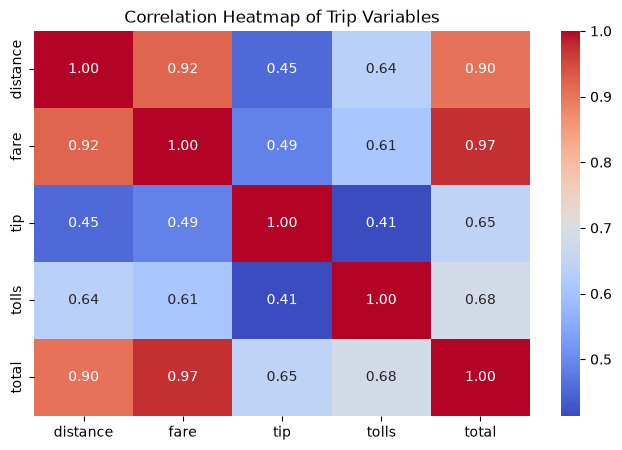

In [43]:

# Step 1: Create correlation matrix
corr_matrix = df[["distance", "fare", "tip", "tolls", "total"]].corr()

# Step 2: Plot heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm",fmt=".2f")
    
plt.title("Correlation Heatmap of Trip Variables")
plt.show()


## ★ Pair Plot
Create a pair plot to visualize the pairwise relationships between distance, fare, tip, and total.
Color the data points according to the pickup_zone column. to compare how different zones
affect these variables.

- Compares multiple variables simultaneously.
- Pickup zones show different behavior patterns.


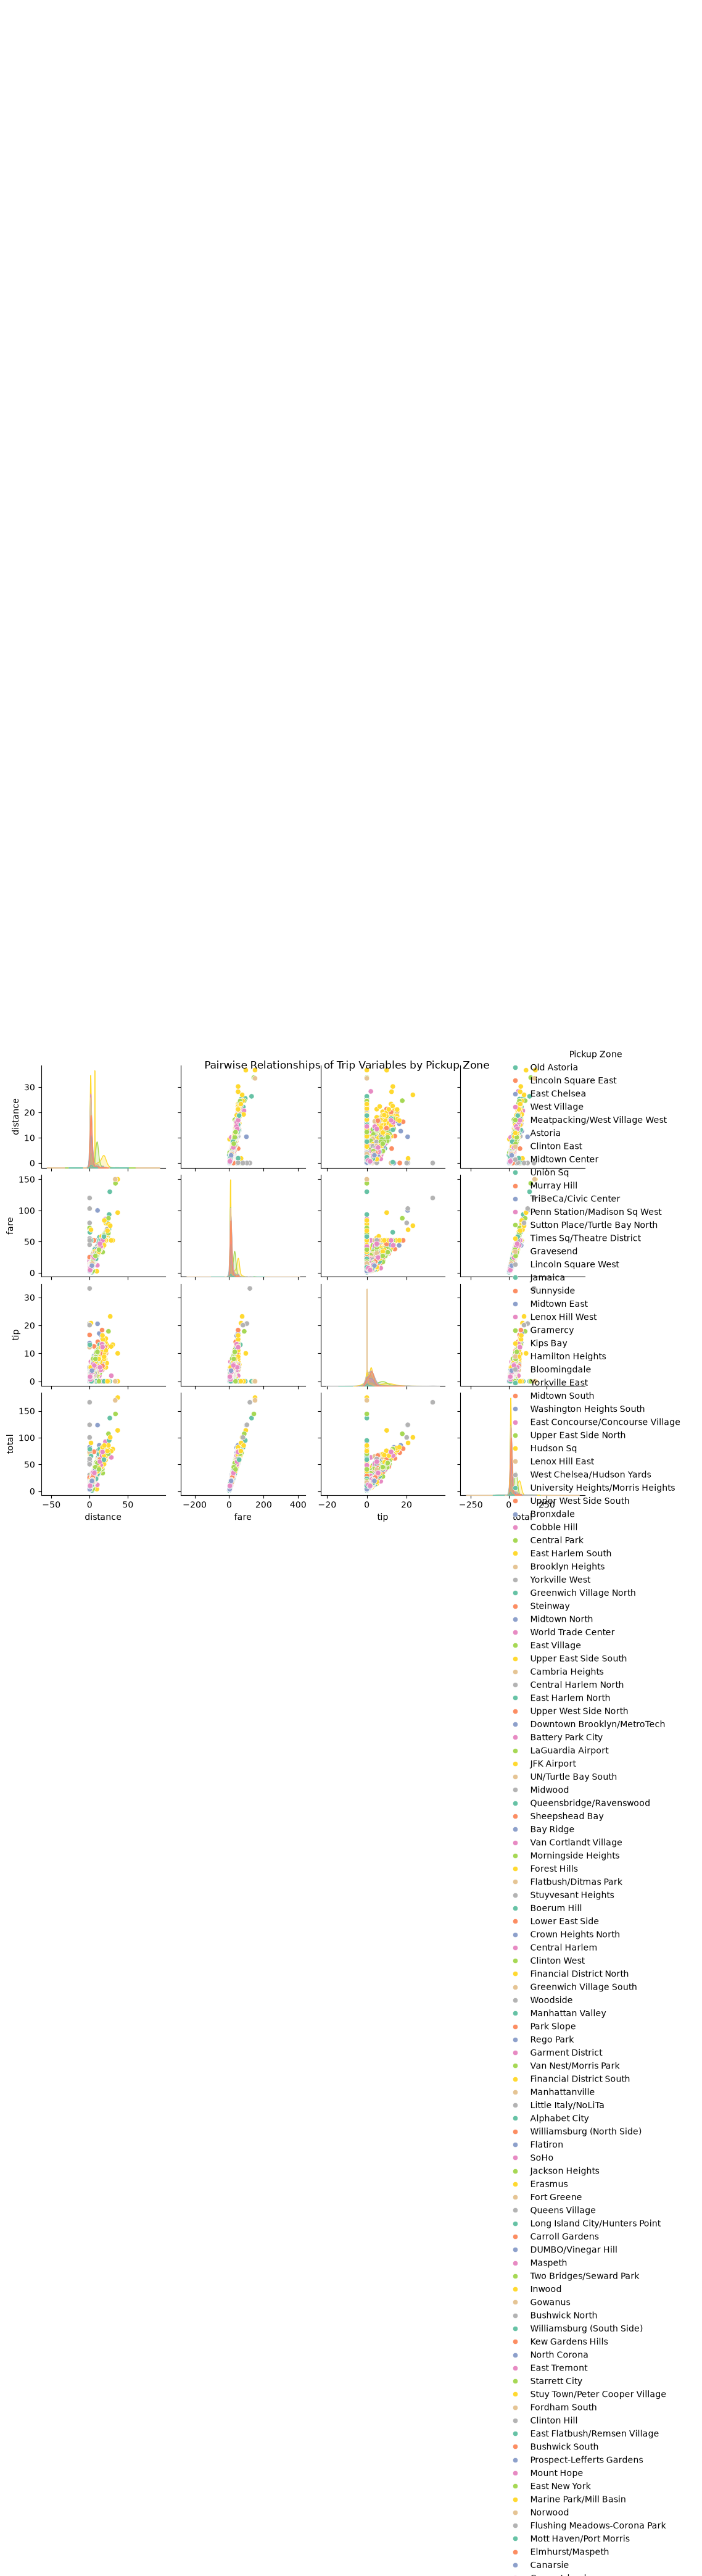

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

selected_vars = ["distance", "fare", "tip", "total"]

# Create pair plot
g = sns.pairplot(
    df[selected_vars + ["pickup_zone"]],
    vars=selected_vars,
    hue="pickup_zone",
    palette="Set2",
    diag_kind="kde",
    height=2
)

# Adjust layout to remove empty top space
g.fig.subplots_adjust(top=0.95, bottom=0.08, left=0.05, right=0.85)

# Add title closer to plots
g.fig.suptitle("Pairwise Relationships of Trip Variables by Pickup Zone", y=0.96)

# Move legend outside neatly
g._legend.set_bbox_to_anchor((1.02, 0.5))
g._legend.set_title("Pickup Zone")

plt.show()


## ★ Violin Plot
- Plot a violin plot to show the distribution of fare for each payment method. Use the payment
method as the categorical axis and fare as the numeric axis to visualize its distribution.

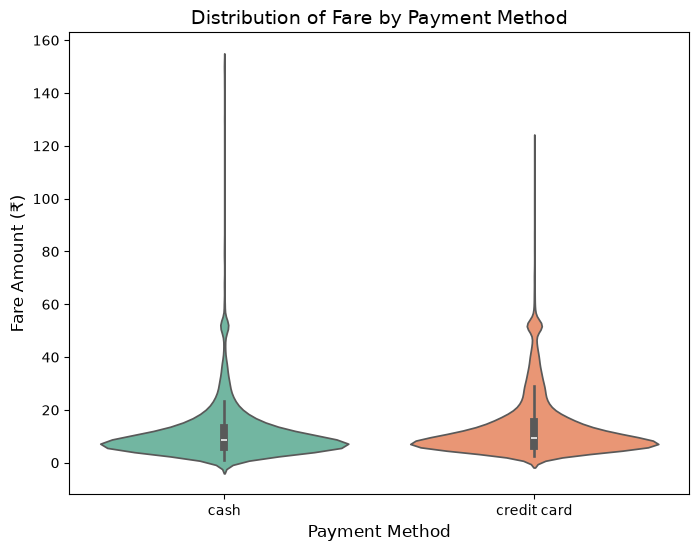

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.violinplot(x="payment", y="fare",data=df,palette="Set2")           


plt.title("Distribution of Fare by Payment Method", fontsize=14)
plt.xlabel("Payment Method", fontsize=12)
plt.ylabel("Fare Amount (₹)", fontsize=12)

plt.show()



# Taxi Data Analysis – Project Summary

## 1. Project Overview

The **Taxi Data Analysis** project was carried out using Python, Pandas, Matplotlib, and Seaborn. The objective was to clean and analyze taxi trip data and create visualizations to understand patterns in **fare, distance, tips, payment methods, pickup boroughs, and customer trip behavior**.

## 2. Data Cleaning

The Seaborn **Taxis dataset** was loaded and examined for missing values. Missing values were identified based on the data type and importance of each column. Numerical values were handled using appropriate statistical methods such as **mean or median**, while categorical values were handled using the **mode** where appropriate. Rows with critical missing information that could not be reasonably imputed were removed to maintain data quality.

The pickup timestamp was also converted into **datetime format** to support time-based analysis.

## 3. Data Visualization

Several visualizations were created using Matplotlib and Seaborn:

* **Line Chart:** Analyzed fare variation over pickup time.
* **Bar Chart:** Compared total fare across different pickup boroughs.
* **Pie Chart:** Showed the distribution of trips by payment method.
* **Histogram:** Examined the distribution of taxi trip distances.
* **Box Plot:** Compared tip distributions across pickup boroughs.
* **Count Plot:** Displayed the number of trips in each pickup borough.
* **Scatter Plot:** Examined the relationship between distance and fare, with boroughs represented using different colors.
* **Heatmap:** Displayed correlations between numerical variables such as distance, fare, tip, tolls, and total.
* **Pair Plot:** Compared pairwise relationships among distance, fare, tip, and total based on pickup zones.
* **Violin Plot:** Examined the distribution of fares for different payment methods.

## 4. Key Findings

The analysis helped identify several patterns in the taxi dataset:

* **Distance and fare** show a positive relationship, meaning longer trips generally tend to have higher fares.
* The **correlation analysis** helped identify relationships among fare, distance, tip, tolls, and total trip amount.
* The number of taxi trips varies across **pickup boroughs**, showing that some areas have higher trip activity than others.
* **Payment methods** are not equally distributed, with some payment methods being used more frequently than others.
* The **distance histogram** shows that most taxi trips are concentrated within shorter travel distances, while a smaller number of trips cover longer distances.
* The box plot and violin plot helped identify the **spread and variation of tips and fares**, including potential outliers.
* The visualizations based on **pickup zones and boroughs** provide a clearer understanding of differences in taxi trip behavior across locations.

## 5. Conclusion

This project demonstrated the complete **data analysis workflow**, including data loading, missing-value handling, exploratory analysis, correlation analysis, and data visualization. Pandas was used for data manipulation, while Matplotlib and Seaborn were used to create meaningful visualizations. The analysis shows how taxi trip data can be transformed into useful insights about **fare, distance, payment methods, tips, and geographic patterns**.

**Tools Used:** Python, Pandas, Matplotlib, Seaborn, Jupyter Notebook 
